# Grupo 3 — Holt-Winters

**Comparação dos quatro modelos:** use a seção final "Avaliação oficial de um passo (T08/T16)". As janelas de vários passos descritas acima são um estudo adicional.

### Estado desta análise

Configuração do estudo multipasso do Grupo 3: **granularidade horária (1 hora)**, **treino 80% / teste 20%** (divisão cronológica, sem embaralhar), **seed 42**, previsão de **168 passos (168 horas = 1 semana)** com validação **walk-forward** de janela expansiva (41 origens, que cobrem todo o período de teste).

A fonte é o Excel tratado do Grupo 3 (`dados_tratados/base-tratada-3.xlsx`), selecionado por `BASE_NAME = 'base-tratada-3'` e resolvido para a chave do manifesto (`poluicao`). **Não há agregação neste notebook**: a série é horária do começo ao fim.

**Diferenças em relação ao notebook base (grupo 1):** `FREQUENCY='h'`, `SEED=42`, `TRAIN_FRAC=0.80`, alvo `PM2.5`; sazonalidade aditiva de período 24; horizontes em horas (168 h / 720 h); **métricas com máscara para os 107 NaN do teste**.

**Ordem de execução (sempre `Restart & Run All`):** importações → configuração global → configuração do Holt-Winters → carga → T04/T05 (sazonalidade) → T08 (walk-forward) → T09 (modelagem) → T16 (comparação por MAE) → T17 (resíduos) → conclusões.


## Importações e Configurações Padrão

In [15]:
import itertools
import json
import math
import random
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, adfuller

# Avisos NÃO são silenciados em bloco: ConvergenceWarning sinaliza otimizador parado no limite
# (parâmetro na fronteira) e precisa aparecer. Cada aviso distinto é mostrado uma única vez.
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning

warnings.simplefilter('once')
warnings.filterwarnings('once', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=ValueWarning)   # ruído de índice/freq já coberto pelos asserts

## Configuração global

In [16]:
BASE_NAME = 'base-tratada-3'
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / 'preparacao_bases.py').is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from preparacao_bases import carregar_base_tratada   # o sys.path precisa estar pronto ANTES deste import

DATA_FILENAME = f'{BASE_NAME}.xlsx'
TARGET_COLUMN = 'PM2.5'

FREQUENCY = 'h'   # granularidade horária (1 hora) (metadados.frequencia = 'h')
FMT_DATA = '%Y-%m-%d %H:%M'     # formato de data/hora nas tabelas de folds
SEED = 42
TRAIN_FRAC = 0.80    # treino 80% / teste 20%, divisão cronológica (sem embaralhar)
TEST_FRAC = round(1 - TRAIN_FRAC, 2)

random.seed(SEED)
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)   # use RNG.* em simulações/bootstrap

# O manifesto indexa as bases pelo nome lógico (bitcoin, trafego, poluicao, clima, ouro).
_manifesto = json.loads((PROJECT_ROOT / 'dados_tratados' / 'manifesto.json').read_text(encoding='utf-8'))
BASE_KEY = next((nome for nome, item in _manifesto['bases'].items()
                 if item['excel'] == DATA_FILENAME), None)
assert BASE_KEY, f'Excel {DATA_FILENAME} não encontrado no manifesto.'

# Valida os parâmetros contra os metadados gravados na própria planilha
_meta = (pd.read_excel(PROJECT_ROOT / 'dados_tratados' / DATA_FILENAME, sheet_name='metadados')
           .set_index('campo')['valor'])
assert str(_meta['frequencia']) == FREQUENCY, f"Frequência da base: {_meta['frequencia']}"
assert int(_meta['seed']) == SEED, f"Seed da base: {_meta['seed']}"
assert math.isclose(float(_meta['treino']), TRAIN_FRAC), f"Treino da base: {_meta['treino']}"

print(f'Fonte: dados_tratados/{DATA_FILENAME} (chave do manifesto: {BASE_KEY})')
print(f'Freq={FREQUENCY} | seed={SEED} | treino/teste={TRAIN_FRAC:.0%}/{TEST_FRAC:.0%}')


Fonte: dados_tratados/base-tratada-3.xlsx (chave do manifesto: poluicao)
Freq=h | seed=42 | treino/teste=80%/20%


## Configuração do Holt-Winters

In [17]:
# Modelo principal (base horária (1 hora))
TREND = 'add'            # 'add', 'mul' ou None
SEASONAL = 'add'   # 'add': evidência estatística de ciclo diário (ACF 24 = 0,022 > limite ±0,012)
                         # força fraca (F_sazonal ≈ 0,035 no T04/T05); o T16 confronta com o modelo sem sazonalidade
SEASONAL_PERIODS = 24    # ciclo diário (24 horas)
DAMPED_TREND = True      # sem amortecimento a tendência é extrapolada linearmente e a previsão longa diverge
OPTIMIZED = True
USE_BOXCOX = False       # alternativa a testar: use_boxcox=0 (log) estabiliza a variância dos resíduos (T17)
INITIALIZATION_METHOD = 'heuristic'   # 'heuristic', 'estimated', 'legacy-heuristic' ou 'known'

# Diagnóstico de sazonalidade (T04): lags candidatos na ACF das diferenças
ACF_MAX_LAG = 200
ACF_CAND = (24, 48, 168)   # 1, 2 e 7 dias em horas

# Exercício de tendência amortecida (φ fixo). com passos de 1 hora, φ <= 0,95 já decai praticamente até o ingênuo em um dia
DAMPING_GRID = [0.99, 0.97, 0.95, 0.90, 0.80, 0.70]

# Avaliação com origem móvel (walk-forward), em horas
HORIZON = 168             # previsão de 168 passos (168 horas = 1 semana)
ORIGIN_STEP = 168         # = HORIZON: janelas de teste sem sobreposição
N_ORIGINS = 41         # cobre o teste inteiro (máximo que cabe no teste; ver verificação na carga)
LONG_HORIZON = 720      # horizonte longo do exercício de amortecimento (720 horas = 30 dias)

# Lags do Ljung-Box (T05/T17) na unidade da base
LB_LAGS = (24, 48, 168)

# Modelo de referência (SARIMA com grid search) — desligue se ficar lento
RUN_SARIMA = False      # grid sazonal m=24 em ~28 mil observações: proibitivo; ligue só se aceitar horas de execução


## Carga da base tratada

O Excel compartilhado é horário e é usado **sem agregação**. Duas séries são mantidas: `y_obs` (com os NaN originais do alvo, usada para **avaliar**) e `y` (com os NaN internos interpolados no tempo, usada apenas para **ajustar** os modelos). Diferentemente da base diária do grupo 1, o teste **não é 100% observado** (107 NaN em 7.013 horas): as métricas mascaram esses pontos.


In [18]:
# Fonte comum T01; granularidade horária (1 hora) (sem agregação).
df, metadados_base = carregar_base_tratada(BASE_KEY, PROJECT_ROOT)
assert metadados_base['frequencia'] == FREQUENCY

# Série observada: preserva os NaN (usada para AVALIAR)
y_obs = df[TARGET_COLUMN].astype(float).asfreq(FREQUENCY)
y_obs.index.name = 'data'

# NaN no treino são interpolados para AJUSTE; no teste ficam em y_obs e são mascarados na avaliação
n_train = int(len(y_obs) * TRAIN_FRAC)
n_nan = int(y_obs.isna().sum())
n_nan_teste = int(y_obs.iloc[n_train:].isna().sum())
print(f'NaN no alvo: {n_nan} no total | {n_nan_teste} no teste (avaliação usa y_obs com máscara)')

# Série para AJUSTAR o modelo — interpolação CAUSAL, feita janela a janela.
# Interpolar a base inteira antes do corte deixaria um NaN anterior à origem ser preenchido
# com um valor observado DEPOIS da origem: vazamento. `preparar_ajuste` é reaplicada a cada
# origem do walk-forward, usando só os pontos que existem dentro daquela janela.
def preparar_ajuste(serie_obs):
    """Série pronta para ajuste, interpolada apenas com os pontos da própria janela."""
    s = serie_obs.interpolate(method='time', limit_area='inside')
    return s.ffill().bfill()      # ffill cobre NaN no fim da janela; bfill, só o começo da base

y = preparar_ajuste(y_obs)        # série completa: índice, contagens e gráficos
assert not y.isna().any()

# Log (T04/T05/T17) só quando toda a série é estritamente positiva; senão, escala original
USE_LOG = bool((y > 0).all())
print('Escala log nos diagnósticos: ' + ('sim' if USE_LOG else 'não (há valores <= 0 na série)'))

if 'mul' in (TREND, SEASONAL) and (y <= 0).any():
    raise ValueError("Componente 'mul' exige série estritamente positiva.")

# Verifica que as janelas do walk-forward e o horizonte longo cabem no período de teste
N_TEST = len(y) - n_train
assert HORIZON + (N_ORIGINS - 1) * ORIGIN_STEP <= N_TEST, 'Janelas excedem o tamanho do teste.'
assert LONG_HORIZON <= N_TEST, 'LONG_HORIZON excede o tamanho do teste.'
MAX_ORIGINS = (N_TEST - HORIZON) // ORIGIN_STEP + 1
print(f'Teste: {N_TEST} passos | Horizonte={HORIZON} | origens={N_ORIGINS} (máx. possível: {MAX_ORIGINS}) '
      f'| horizonte longo={LONG_HORIZON}')

print(f'{len(y)} passos | {y.index.min():{FMT_DATA}} a {y.index.max():{FMT_DATA}} '
      f'| treino={n_train} | teste={N_TEST}')
y.head()


NaN no alvo: 925 no total | 107 no teste (avaliação usa y_obs com máscara)
Escala log nos diagnósticos: sim
Teste: 7013 passos | Horizonte=168 | origens=41 (máx. possível: 41) | horizonte longo=720
35064 passos | 2013-03-01 00:00 a 2017-02-28 23:00 | treino=28051 | teste=7013


data
2013-03-01 00:00:00    4.0
2013-03-01 01:00:00    8.0
2013-03-01 02:00:00    7.0
2013-03-01 03:00:00    6.0
2013-03-01 04:00:00    3.0
Freq: h, Name: PM2.5, dtype: float64

# 2. Sazonalidade

## T04 — Decomposição STL

Decomposição STL (sobre o log do alvo, apenas no treino) e interpretação gráfica da tendência, incluindo períodos de alta, queda e estabilidade.

> **Nota (base poluicao, granularidade horária (1 hora)):** na ACF das diferenças, os lags 24, 48 e 168 valem 0,022 / 0,007 / 0,011 contra limite de ±1,96/√n ≈ ±0,012 — só o lag 24 passa, e por pouco; a STL com período 24 dá `F_sazonal ≈ 0,035` (fraca) e `F_tend ≈ 0,606`. Há evidência estatística de ciclo diário, mas força fraca: o modelo principal mantém `SEASONAL = 'add'` com período 24 e o T16 confronta com o Holt sem sazonalidade.


Escala do diagnóstico (T04/T05): log
Limite 95%: ±0.012
ACF nos candidatos: {24: 0.012, 48: 0.025, 168: 0.012}
Maior pico geral: lag 96 (ACF=0.028) — sem interpretação sazonal
Evidência de ciclo nos lags candidatos: coerente com SEASONAL=add.
SEASONAL_PERIODS=24 (ciclo diário de 24 h), usado na STL e no grid do SARIMA.


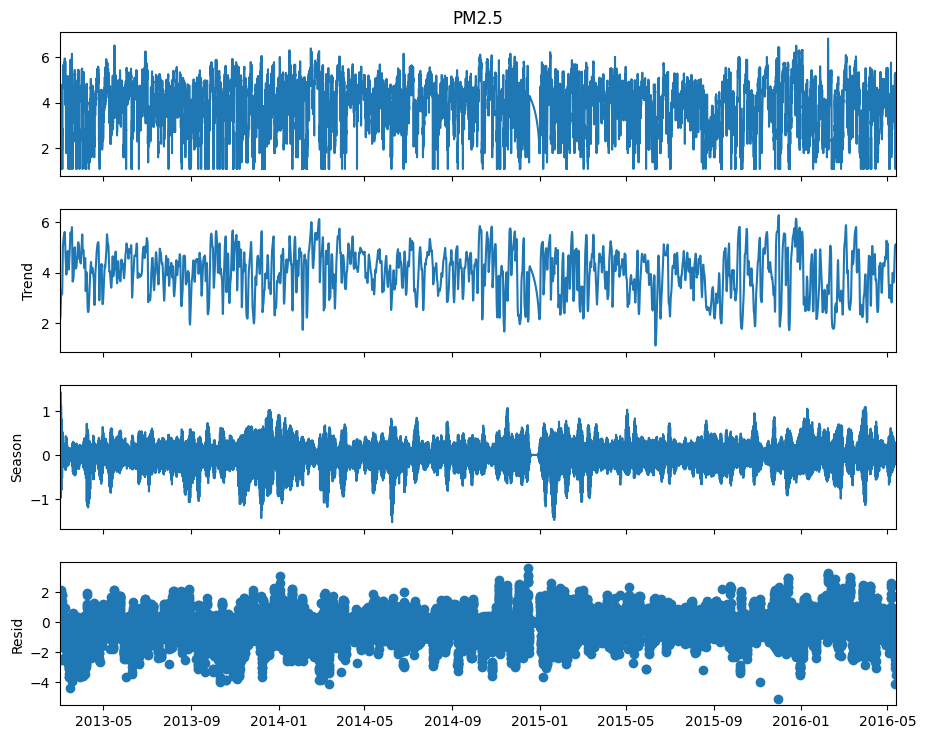

Força da tendência (F_tend) = 0.662 | Força da sazonalidade (F_saz) = 0.066


,tendencia_media,passos_no_ano,variacao_%
data,,,
2013,81.49,7344,NaN
2014,86.53,8760,6.19
2015,77.28,8760,-10.69
2016,62.66,3187,-18.92


In [19]:
def detectar_periodo_sazonal(serie, max_lag=60, candidatos=(7, 14, 30)):
    """Confere SEASONAL_PERIODS na série diferenciada (remove a tendência).

    Devolve um dicionário com o lag de maior ACF, o limite de 95% (±1,96/sqrt(n)) e a ACF
    nos candidatos. Só há evidência de sazonalidade se algum candidato superar o limite;
    o pico geral pode ser ruído (muitos lags testados).
    """
    dif = serie.diff().dropna()
    n = len(dif)
    valores = acf(dif, nlags=max_lag, fft=True)
    limite = 1.96 / np.sqrt(n)
    lag_pico = int(np.argmax(valores[2:]) + 2)          # ignora lags 0 e 1
    acf_cand = {c: float(valores[c]) for c in candidatos if c <= max_lag}
    return {'lag_pico': lag_pico, 'acf_pico': float(valores[lag_pico]), 'limite': float(limite),
            'acf_candidatos': acf_cand, 'evidencia': any(v > limite for v in acf_cand.values())}

# Diagnóstico exploratório SÓ no treino (não usa o teste para decidir o modelo)
y_treino = preparar_ajuste(y_obs.iloc[:n_train])   # mesmo tratamento causal do walk-forward
# Log apenas se a série for estritamente positiva; senão o diagnóstico usa a própria série
serie_diag = np.log(y_treino) if USE_LOG else y_treino
escala = 'log' if USE_LOG else 'original'
print(f'Escala do diagnóstico (T04/T05): {escala}')

res_acf = detectar_periodo_sazonal(serie_diag, max_lag=ACF_MAX_LAG, candidatos=ACF_CAND)
print(f"Limite 95%: ±{res_acf['limite']:.3f}")
print('ACF nos candidatos:', {k: round(v, 3) for k, v in res_acf['acf_candidatos'].items()})
print(f"Maior pico geral: lag {res_acf['lag_pico']} (ACF={res_acf['acf_pico']:.3f}) — sem interpretação sazonal")

if res_acf['evidencia'] and SEASONAL is None:
    print('ATENÇÃO: há evidência de sazonalidade, mas SEASONAL=None. Revise a configuração.')
elif not res_acf['evidencia']:
    print(f'Sem evidência de ciclo nos lags candidatos: coerente com SEASONAL={SEASONAL}.')
else:
    print(f'Evidência de ciclo nos lags candidatos: coerente com SEASONAL={SEASONAL}.')
print(f'SEASONAL_PERIODS={SEASONAL_PERIODS} (ciclo diário de 24 h), usado na STL e no grid do SARIMA.')

# Decomposição STL
stl_res = STL(serie_diag, period=SEASONAL_PERIODS, robust=True).fit()
fig = stl_res.plot()
fig.set_size_inches(10, 8)
plt.show()

# Força da tendência e da sazonalidade (Wang, Smith & Hyndman, 2006)
F_tend = max(0, 1 - stl_res.resid.var() / (stl_res.trend + stl_res.resid).var())
F_saz = max(0, 1 - stl_res.resid.var() / (stl_res.seasonal + stl_res.resid).var())
print(f'Força da tendência (F_tend) = {F_tend:.3f} | Força da sazonalidade (F_saz) = {F_saz:.3f}')

# Leitura numérica da tendência: alta / queda / estabilidade por ano (na escala da série)
tend_nivel = np.exp(stl_res.trend) if USE_LOG else stl_res.trend
g = tend_nivel.groupby(tend_nivel.index.year)
tend_anual = g.mean()
tabela_tend = pd.DataFrame({'tendencia_media': tend_anual, 'passos_no_ano': g.size()})
if USE_LOG:
    tabela_tend['variacao_%'] = tend_anual.pct_change() * 100
else:
    tabela_tend['variacao_abs'] = tend_anual.diff()   # série com zero/negativos: variação relativa não faz sentido
display(tabela_tend.round(2))


## T05 — Força da sazonalidade e resíduos

Cálculo da força da sazonalidade e análise do componente residual.

In [20]:
# T05 — Força da sazonalidade e resíduos
def forca(resid, componente):
    """Força (Hyndman): max(0, 1 - Var(R) / Var(componente + R)). Próxima de 1 => componente forte."""
    return max(0.0, 1 - np.var(resid) / np.var(componente + resid))

F_sazonal = forca(stl_res.resid, stl_res.seasonal)
F_tendencia = forca(stl_res.resid, stl_res.trend)
print(f'Força da sazonalidade: {F_sazonal:.3f}')
print(f'Força da tendência:    {F_tendencia:.3f}')

# Aditivo x multiplicativo. Em log, sazonalidade multiplicativa => amplitude (em log) constante.
LINHAS_POR_ANO = {'D': 365, 'h': 8760, 'W-FRI': 52}[FREQUENCY]
anos_completos = [a for a in stl_res.seasonal.index.year.unique()
                  if (stl_res.seasonal.index.year == a).sum() >= LINHAS_POR_ANO]
def amp_nivel(sazonal, tendencia):
    amp = sazonal.groupby(sazonal.index.year).agg(lambda s: s.max() - s.min())
    niv = tendencia.groupby(tendencia.index.year).mean()
    return amp, niv

escala = 'log' if USE_LOG else 'original'
amp_d, niv_d = amp_nivel(stl_res.seasonal, stl_res.trend)
print(f'Anos completos usados: {anos_completos} (n={len(anos_completos)}, amostra pequena)')
if USE_LOG:
    tend_p = np.exp(stl_res.trend)
    amp_p, niv_p = amp_nivel(tend_p * (np.exp(stl_res.seasonal) - 1), tend_p)
    print(f'Corr. amplitude × nível, escala log:     {amp_d.loc[anos_completos].corr(niv_d.loc[anos_completos]):.2f} '
          '(perto de 0 => amplitude relativa constante => compatível com multiplicativa)')
    print(f'Corr. amplitude × nível, escala original: {amp_p.loc[anos_completos].corr(niv_p.loc[anos_completos]):.2f} '
          '(esperado alto sob sazonalidade multiplicativa; F_saz ≈ 0 => conclusão fraca)')
else:
    print(f'Corr. amplitude × nível, escala {escala}: {amp_d.loc[anos_completos].corr(niv_d.loc[anos_completos]):.2f} '
          '(perto de 0 => amplitude relativa constante)')

# Componente residual (escala do diagnóstico)
r = stl_res.resid
print(f'\nResíduo STL (escala {escala}):')
display(r.describe().round(4).to_frame('resid'))
print(f'Assimetria: {stats.skew(r):.2f} | Curtose em excesso: {stats.kurtosis(r):.2f} (normal = 0)')
print('Ljung-Box (autocorrelação do resíduo STL):')
display(acorr_ljungbox(r, lags=list(LB_LAGS)).round(4))
print(f'Teste ARCH (variância não constante), p = {het_arch(r, nlags=7)[1]:.4f}')
print('Desvio padrão do resíduo por ano:')
display(r.groupby(r.index.year).std().round(4).to_frame('std_resid'))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(r)
ax[0].axhline(0, color='k', lw=0.8)
ax[0].set_title(f'Resíduo STL no tempo ({escala})')
ax[1].hist(r, bins=50)
ax[1].set_title('Distribuição do resíduo')
plt.tight_layout()
plt.show()


Força da sazonalidade: 0.066
Força da tendência:    0.662
Anos completos usados: [2014, 2015] (n=2, amostra pequena)
Corr. amplitude × nível, escala log:     1.00 (perto de 0 => amplitude relativa constante => compatível com multiplicativa)
Corr. amplitude × nível, escala original: -1.00 (esperado alto sob sazonalidade multiplicativa; F_saz ≈ 0 => conclusão fraca)

Resíduo STL (escala log):


,resid
count,28051.0000
mean,-0.0943
std,0.6264
min,-5.0845
25%,-0.1914
50%,-0.0105
75%,0.1332
max,3.5631


Assimetria: -1.25 | Curtose em excesso: 7.14 (normal = 0)
Ljung-Box (autocorrelação do resíduo STL):


KeyboardInterrupt: 

# 3. Validação temporal

## T08 — Validação walk-forward

Protocolo walk-forward de janela expansiva. As origens partem do **corte treino/teste (80/20%)** e avançam de `ORIGIN_STEP` em `ORIGIN_STEP` horas; cada janela de teste tem `HORIZON` horas e cabe inteira no período de teste. O hold-out simples é a própria partição 80/20% (28.051 horas de treino / 7.013 de teste).


In [ ]:
# T08 — Validação walk-forward (janela expansiva)
def make_origins(n_obs, n_train, horizon, n_origins, step):
    """Tamanhos de treino (origens), a partir do corte treino/teste (80/20%).
    Cada janela de teste cabe dentro do período de teste."""
    origens = [n_train + k * step for k in range(n_origins)]
    assert origens[-1] + horizon <= n_obs, (
        f'As {n_origins} origens com passo {step} excedem a base; '
        f'máximo = {(n_obs - n_train - horizon) // step + 1}.')
    return origens


def walk_forward(serie, forecast_fn, origins, horizon, serie_avaliacao=None):
    """Para cada origem: ajusta só com o passado e prevê `horizon` passos à frente.
    `serie_avaliacao` (opcional) fornece o y_real com os NaN originais; os pontos não
    observados são mascarados nas métricas (a avaliação não imputa NaN)."""
    aval = serie if serie_avaliacao is None else serie_avaliacao
    partes = []
    for o in origins:
        treino = preparar_ajuste(serie.iloc[:o])   # interpolação causal: só o passado da janela
        teste = serie.iloc[o:o + horizon]
        assert len(teste) == horizon, f'Janela incompleta na origem {o}.'
        prev = np.asarray(forecast_fn(treino, horizon))
        partes.append(pd.DataFrame({
            'origem': treino.index[-1], 'data': teste.index, 'h': np.arange(1, horizon + 1),
            'y_real': aval.iloc[o:o + horizon].values, 'y_prev': prev,
        }))
    return pd.concat(partes, ignore_index=True)


n_train = int(len(y) * TRAIN_FRAC)                      # 28051
ORIGINS = make_origins(len(y), n_train, HORIZON, N_ORIGINS, ORIGIN_STEP)
assert ORIGINS[0] >= 2 * SEASONAL_PERIODS, 'Treino da 1ª origem menor que 2 ciclos sazonais.'
# NaN de y_obs dentro das janelas de teste são esperados: a avaliação usa máscara
n_nan_janelas = int(y_obs.iloc[ORIGINS[0]:].isna().sum())
print(f'NaN do alvo dentro das janelas de teste: {n_nan_janelas} (mascarados nas métricas)')

# Hold-out simples = partição 80/20% da base (28.051 treino / 7.013 teste)
train = preparar_ajuste(y_obs.iloc[:n_train])   # idêntico ao treino da 1ª origem
test = y_obs.iloc[n_train:]

display(pd.DataFrame([{
    'fold': i + 1, 'n_treino': o, 'treino_ate': y.index[o - 1].strftime(FMT_DATA),
    'teste_de': y.index[o].strftime(FMT_DATA), 'teste_ate': y.index[o + HORIZON - 1].strftime(FMT_DATA),
} for i, o in enumerate(ORIGINS)]))


NaN do alvo dentro das janelas de teste: 107 (mascarados nas métricas)


,fold,n_treino,treino_ate,teste_de,teste_ate
0,1,28051,2016-05-12 18:00,2016-05-12 19:00,2016-05-19 18:00
1,2,28219,2016-05-19 18:00,2016-05-19 19:00,2016-05-26 18:00
2,3,28387,2016-05-26 18:00,2016-05-26 19:00,2016-06-02 18:00
3,4,28555,2016-06-02 18:00,2016-06-02 19:00,2016-06-09 18:00
4,5,28723,2016-06-09 18:00,2016-06-09 19:00,2016-06-16 18:00
5,6,28891,2016-06-16 18:00,2016-06-16 19:00,2016-06-23 18:00
6,7,29059,2016-06-23 18:00,2016-06-23 19:00,2016-06-30 18:00
7,8,29227,2016-06-30 18:00,2016-06-30 19:00,2016-07-07 18:00
8,9,29395,2016-07-07 18:00,2016-07-07 19:00,2016-07-14 18:00
9,10,29563,2016-07-14 18:00,2016-07-14 19:00,2016-07-21 18:00


# 4. Modelagem Holt-Winters

## T09 — Holt-Winters

Modelo principal: **Holt com tendência aditiva amortecida e sazonalidade aditiva de período 24 (evidência fraca de ciclo diário no T04/T05). A família Holt-Winters completa (variantes aditiva e multiplicativa, período 24) e o SES são ajustados como comparação, junto com as referências ingênuas. Esta seção: (1) ajuste no treino e parâmetros α, β, γ e φ; (2) walk-forward de todos os modelos com as **mesmas origens**; (3) sensibilidade ao amortecimento; (4) SARIMA como referência (quando `RUN_SARIMA = True`).


In [ ]:
def ajustar_hw(serie, trend=TREND, seasonal=SEASONAL, damped=DAMPED_TREND, damping_trend=None,
               seasonal_periods=SEASONAL_PERIODS, use_boxcox=USE_BOXCOX):
    """Ajusta um Holt-Winters com os padrões da configuração; qualquer argumento pode ser sobrescrito."""
    modelo = ExponentialSmoothing(
        serie, trend=trend, damped_trend=bool(damped and trend), seasonal=seasonal,
        seasonal_periods=seasonal_periods if seasonal else None,
        use_boxcox=use_boxcox, initialization_method=INITIALIZATION_METHOD)
    kw = {'optimized': OPTIMIZED}
    if damping_trend is not None:
        kw['damping_trend'] = damping_trend      # φ fixo (exercício de sensibilidade)
    return modelo.fit(**kw)


def parametros(fit):
    """Parâmetros de suavização estimados: α (nível), β (tendência), γ (sazonal) e φ (amortecimento)."""
    p = fit.params
    return {'alpha': p.get('smoothing_level'), 'beta': p.get('smoothing_trend'),
            'gamma': p.get('smoothing_seasonal'), 'phi': p.get('damping_trend')}


# Ajustes no treino (hold-out 80/20%). Mesmo treino de 28.051 horas para todos os modelos
# Catálogo único de configurações Holt-Winters: a MESMA lista alimenta o hold-out (T09),
# o walk-forward (T16) e o diagnóstico de resíduos (T17). O modelo configurado entra sempre,
# com nome próprio, e configurações repetidas são removidas para não duplicar colunas no T16.
NOME_CFG = 'HW configurado (modelo principal)'
CFG_MODELO = {'trend': TREND, 'damped_trend': bool(DAMPED_TREND and TREND), 'seasonal': SEASONAL,
              'seasonal_periods': SEASONAL_PERIODS if SEASONAL else None}


def assinatura(kw):
    """Identidade de uma configuração, para não repetir o mesmo modelo sob dois nomes."""
    return (kw.get('trend'), kw.get('seasonal'), bool(kw.get('damped_trend', False)),
            kw.get('seasonal_periods') if kw.get('seasonal') else None)


_positivo = bool((train > 0).all())      # variantes 'mul' exigem série estritamente positiva
_candidatos = [
    (NOME_CFG, CFG_MODELO),
    ('SES (sem tend./saz.)', {}),
    ('Holt amortecido (sem saz.)', {'trend': 'add', 'damped_trend': True}),
    ('HW aditivo', {'trend': 'add', 'seasonal': 'add', 'seasonal_periods': SEASONAL_PERIODS}),
    ('HW aditivo amortecido', {'trend': 'add', 'damped_trend': True,
                               'seasonal': 'add', 'seasonal_periods': SEASONAL_PERIODS}),
]
if _positivo:
    _candidatos += [
        ('HW multiplicativo', {'trend': 'add', 'seasonal': 'mul', 'seasonal_periods': SEASONAL_PERIODS}),
        ('HW multiplicativo amortecido', {'trend': 'add', 'damped_trend': True,
                                          'seasonal': 'mul', 'seasonal_periods': SEASONAL_PERIODS}),
    ]
else:
    print("Série com zeros/negativos: variantes 'mul' ficam fora do catálogo (exigem série positiva).")

CATALOGO, _vistos = {}, {}
for _nome, _kw in _candidatos:           # o configurado vem primeiro e tem prioridade de nome
    _s = assinatura(_kw)
    if _s in _vistos:
        print(f'{_nome}: mesma configuração de "{_vistos[_s]}" — não duplicado no catálogo.')
        continue
    _vistos[_s] = _nome
    CATALOGO[_nome] = _kw
assert NOME_CFG in CATALOGO, 'O modelo configurado precisa estar no catálogo.'
print(f'Catálogo com {len(CATALOGO)} configurações: {list(CATALOGO)}')

_hw = lambda **kw: ExponentialSmoothing(train, initialization_method=INITIALIZATION_METHOD, **kw).fit()
fits_holdout = {nome: _hw(**kw) for nome, kw in CATALOGO.items()}
assert all(len(f.resid) == n_train for f in fits_holdout.values()), (
    'fits_holdout foi ajustado com outra janela de treino.')
fit_cfg = fits_holdout[NOME_CFG]         # modelo configurado (TREND / SEASONAL / DAMPED_TREND)

tabela_param = pd.DataFrame({nome: {**parametros(f), 'AIC': f.aic}
                             for nome, f in fits_holdout.items()}).T
print('Parâmetros estimados no treino:')
display(tabela_param.round(4))

# Parâmetro na fronteira => o otimizador foi barrado pelos limites do statsmodels; o valor não é
# um ótimo interior e a leitura do modelo muda (φ no piso = tendência praticamente desligada).
LIMITES = {'alpha': (0.0, 1.0), 'beta': (0.0, 1.0), 'gamma': (0.0, 1.0), 'phi': (0.8, 0.995)}   # limites reais do statsmodels 0.14 (ExponentialSmoothing._setup_bounds)
for _nome in tabela_param.index:
    _ps = [f'{p}={tabela_param.loc[_nome, p]:.4f}' for p, (lo, hi) in LIMITES.items()
           if p in tabela_param.columns and pd.notna(tabela_param.loc[_nome, p])
           and (np.isclose(tabela_param.loc[_nome, p], lo, atol=1e-4)
                or np.isclose(tabela_param.loc[_nome, p], hi, atol=1e-4))]
    if _ps:
        print(f'ATENÇÃO — {_nome}: parâmetro(s) no limite do otimizador: {", ".join(_ps)}')


Parâmetros estimados no treino (α≈1 => o nível acompanha quase só o último valor):


,alpha,beta,gamma,phi,AIC
SES (sem tend./saz.),1.0000,NaN,NaN,NaN,169988.2058
HW aditivo,0.9953,0.0,0.0047,NaN,170203.0331
HW multiplicativo,0.9842,0.0,0.0045,NaN,175721.0827
HW multiplicativo amortecido,0.9841,0.0,0.0043,0.8521,175810.6800
Holt amortecido (configurado),0.9953,0.0,0.0047,0.9950,170204.4824


In [ ]:
# Walk-forward de todos os modelos, com as MESMAS origens e horizonte
def hw_forecaster(**kw):
    def f(treino, h):
        return ExponentialSmoothing(treino, initialization_method=INITIALIZATION_METHOD, **kw).fit().forecast(h)
    return f

def naive_forecaster(treino, h):
    return np.repeat(treino.iloc[-1], h)                    # repete o último valor

def naive_drift_forecaster(treino, h):
    deriva = (treino.iloc[-1] - treino.iloc[0]) / (len(treino) - 1)   # variação média por passo
    return treino.iloc[-1] + deriva * np.arange(1, h + 1)

modelos = {nome: hw_forecaster(**kw) for nome, kw in CATALOGO.items()}   # mesmo catálogo do T09
modelos['Ingênuo'] = naive_forecaster
modelos['Ingênuo c/ deriva'] = naive_drift_forecaster
assert NOME_CFG in modelos, 'O modelo configurado precisa entrar no walk-forward.'

wf_resultados = {nome: walk_forward(y_obs, f, ORIGINS, HORIZON, y_obs) for nome, f in modelos.items()}

# Alarmes: mesmas origens e sem NaN nas previsões (y_real pode ter NaN: pontos não observados)
_ref = set(next(iter(wf_resultados.values()))['origem'])
assert len(_ref) == N_ORIGINS
assert all(set(d['origem']) == _ref for d in wf_resultados.values()), 'Modelos com origens diferentes.'
assert all(d['y_prev'].notna().all() for d in wf_resultados.values()), 'Há NaN nas previsões.'
n_obs_min = min(int(d['y_real'].notna().sum()) for d in wf_resultados.values())
print(f'{len(_ref)} folds | origens de {min(_ref):{FMT_DATA}} a {max(_ref):{FMT_DATA}} | '
      f'{len(wf_resultados)} modelos | menor nº de pontos observados por fold: {n_obs_min}')


41 folds | origens de 2016-05-12 18:00 a 2017-02-16 18:00 | 7 modelos | menor nº de pontos observados por fold: 6783


### Sensibilidade da tendência amortecida (φ)

Sem amortecimento a tendência é somada linearmente e a previsão diverge com o horizonte. Com ``damped_trend=True`` cada passo
futuro da tendência é multiplicado por uma potência de φ (0 < φ < 1). Compara-se φ estimado por MLE com φ fixo, em um horizonte longo.

,phi,valor_final,variacao_%_vs_sem_damping,AIC,RMSE,MAE,MAPE_%
0,sem damping,73.95,0.00,170203.03,36.15,28.68,121.41
1,MLE (0.9950),10.04,-86.42,170204.48,52.31,40.42,73.32
2,0.99,10.04,-86.42,170204.49,52.31,40.42,73.32
3,0.97,10.04,-86.42,170204.51,52.31,40.42,73.32
4,0.95,10.04,-86.42,170204.52,52.31,40.42,73.32
5,0.9,10.04,-86.42,170204.52,52.31,40.43,73.32
6,0.8,8.97,-87.87,170125.53,53.12,41.27,73.80
7,0.7,8.68,-88.26,169900.57,53.77,41.92,74.41
8,ingênuo,10.00,-86.48,NaN,56.94,45.43,75.50


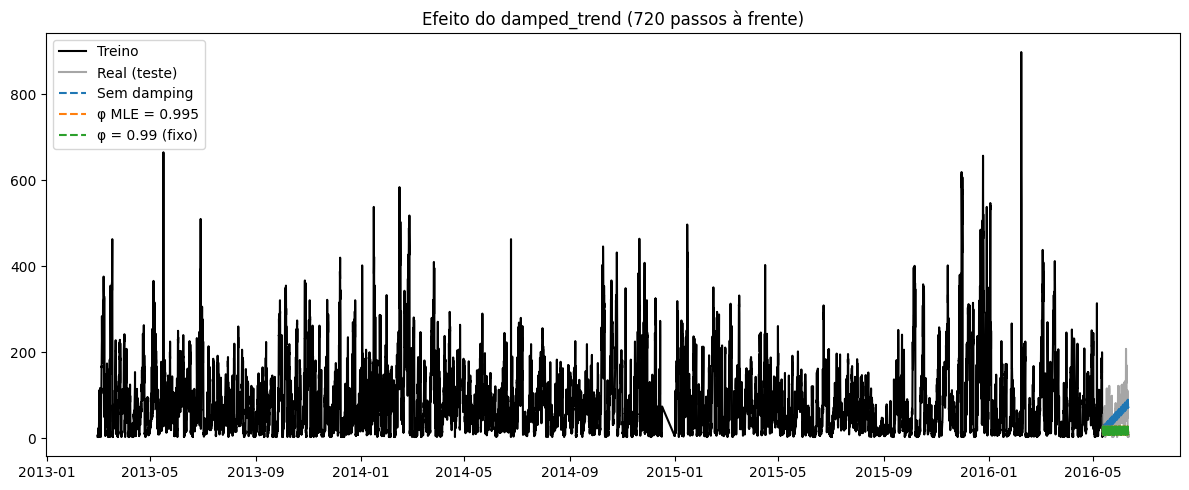

In [ ]:
# Efeito do damped_trend — só avaliação; φ NÃO é escolhido olhando o teste
real_h = y_obs.iloc[n_train:n_train + LONG_HORIZON]
assert len(real_h) == LONG_HORIZON, 'LONG_HORIZON excede o tamanho do teste.'
mascara = real_h.notna().values          # pontos não observados ficam fora das métricas
assert mascara.any(), 'Janela do horizonte longo sem nenhum ponto observado.'

def metricas(fc):
    e = (real_h.values - fc.values)[mascara]
    y_abs = np.abs(real_h.values[mascara])
    y_abs = np.where(y_abs > 0, y_abs, np.nan)   # MAPE não está definido em y = 0
    return {'RMSE': np.sqrt((e ** 2).mean()), 'MAE': np.abs(e).mean(),
            'MAPE_%': np.nanmean(np.abs(e) / y_abs) * 100}

sem_damping = ajustar_hw(train, trend='add', seasonal=SEASONAL, damped=False)
mle = ajustar_hw(train, trend='add', seasonal=SEASONAL, damped=True)
phi_mle = parametros(mle)['phi']

fc_base = sem_damping.forecast(LONG_HORIZON)
fc_mle = mle.forecast(LONG_HORIZON)
valor_base = fc_base.iloc[-1]
fc_naive = pd.Series(np.repeat(train.iloc[-1], LONG_HORIZON), index=fc_base.index)

linhas = [
    {'phi': 'sem damping', 'valor_final': valor_base, 'variacao_%_vs_sem_damping': 0.0,
     'AIC': sem_damping.aic, **metricas(fc_base)},
    {'phi': f'MLE ({phi_mle:.4f})', 'valor_final': fc_mle.iloc[-1],
     'variacao_%_vs_sem_damping': (fc_mle.iloc[-1] / valor_base - 1) * 100,
     'AIC': mle.aic, **metricas(fc_mle)},
]
fc_fixos = {}
for phi in DAMPING_GRID:
    fit = ajustar_hw(train, trend='add', seasonal=SEASONAL, damped=True, damping_trend=phi)
    fc_fixos[phi] = fit.forecast(LONG_HORIZON)
    linhas.append({'phi': phi, 'valor_final': fc_fixos[phi].iloc[-1],
                   'variacao_%_vs_sem_damping': (fc_fixos[phi].iloc[-1] / valor_base - 1) * 100,
                   'AIC': fit.aic, **metricas(fc_fixos[phi])})
linhas.append({'phi': 'ingênuo', 'valor_final': fc_naive.iloc[-1],
               'variacao_%_vs_sem_damping': (fc_naive.iloc[-1] / valor_base - 1) * 100,
               'AIC': np.nan, **metricas(fc_naive)})
display(pd.DataFrame(linhas).round(2))

phi_plot = 0.99 if 0.99 in fc_fixos else DAMPING_GRID[0]   # distinto do MLE no gráfico
plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, color='black', label='Treino')
plt.plot(real_h.index, real_h.values, color='gray', alpha=0.7, label='Real (teste)')
plt.plot(fc_base.index, fc_base.values, ls='--', label='Sem damping')
plt.plot(fc_mle.index, fc_mle.values, ls='--', label=f'φ MLE = {phi_mle:.3f}')
plt.plot(fc_fixos[phi_plot].index, fc_fixos[phi_plot].values, ls='--', label=f'φ = {phi_plot} (fixo)')
plt.legend()
plt.title(f'Efeito do damped_trend ({LONG_HORIZON} passos à frente)')
plt.tight_layout()
plt.show()


### Modelo de referência — SARIMA (grid search)

Grid reduzido e justificado pela série: **d = 1** (o ADF indica raiz unitária no nível e estacionariedade na primeira diferença), **D = 0** (o ciclo sazonal é tratado pelo próprio Holt-Winters), p, q ≈ 0–2 e P, Q ≈ 0–1 com m = ``SEASONAL_PERIODS``, mais a opção sem componente sazonal.
Para não vazar informação do futuro, o grid é feito só com o treino da **primeira origem** (o treino original de 28.051 horas) e a ordem escolhida fica congelada
para todos os folds (o MAE do teste não entra na escolha).

> `RUN_SARIMA = False` nesta base: o grid sazonal (m = 24) em ~28 mil observações horárias é proibitivo em `statsmodels.SARIMAX`; se ligar, comece reduzindo o grid.

> **Atenção ao critério (AIC):** o `aic` do `SARIMAX` **não é comparável** entre modelos com componentes sazonais diferentes, porque cada um descarta um número
> diferente de observações iniciais no cálculo da verossimilhança (`loglikelihood_burn` cresce com a ordem sazonal). Isso fazia um termo sazonal
> com coeficiente ≈ 0 parecer ganhar ~109 pontos de AIC no caso diário. Aqui o AIC é recalculado descartando as **mesmas** `2×m` observações
> iniciais de todos os modelos (`AIC_comparavel`).


In [ ]:
if RUN_SARIMA:
    treino_grid = preparar_ajuste(y_obs.iloc[:ORIGINS[0]])          # só o treino original (28.051 horas)

    # d=1 e D=0 justificados por testes no treino
    print(f'ADF (H0: raiz unitária) — nível: p={adfuller(treino_grid)[1]:.4f} | '
          f'1ª diferença: p={adfuller(treino_grid.diff().dropna())[1]:.4f}')
    pdq = [(p, 1, q) for p, q in itertools.product(range(3), range(3))]
    # sem sazonalidade (0,0,0,0) + variantes sazonais (m = SEASONAL_PERIODS), para comparar
    sazonal_pdq = [(0, 0, 0, 0)] + [(P, 0, Q, SEASONAL_PERIODS)
                                    for P, Q in itertools.product(range(2), range(2)) if (P, Q) != (0, 0)]

    BURN_COMUM = 2 * SEASONAL_PERIODS          # mesmas observações iniciais descartadas em todos os modelos
    resultados, falhas = [], 0
    for order in pdq:
        for seasonal_order in sazonal_pdq:
            try:
                res = SARIMAX(treino_grid, order=order, seasonal_order=seasonal_order,
                              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                ll = np.nansum(res.llf_obs[BURN_COMUM:])
                resultados.append({'order': order, 'seasonal_order': seasonal_order,
                                   'AIC_comparavel': -2 * ll + 2 * len(res.params),
                                   'AIC_statsmodels': res.aic, 'burn': res.model.loglikelihood_burn})
            except Exception:
                falhas += 1
    print(f'{len(resultados)} modelos ajustados, {falhas} falhas')

    grid_sarima = pd.DataFrame(resultados).sort_values('AIC_comparavel').reset_index(drop=True)
    assert grid_sarima['burn'].max() <= BURN_COMUM, 'BURN_COMUM menor que o burn de algum modelo.'
    display(grid_sarima.head(10).round(1))
    melhor = grid_sarima.iloc[0]
    print(f"Escolhido: order={melhor['order']}, seasonal_order={melhor['seasonal_order']}")

    def sarima_forecaster(treino, h):
        return SARIMAX(treino, order=melhor['order'], seasonal_order=melhor['seasonal_order'],
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False).forecast(h)

    wf_resultados['SARIMA (grid AIC)'] = walk_forward(y_obs, sarima_forecaster, ORIGINS, HORIZON, y_obs)


# 5. Avaliação

## T16 — Comparação por MAE

Consolidação do MAE fora da amostra por base e modelo, incluindo número de vitórias e posição média.

MAE por fold:


,SES (sem tend./saz.),HW aditivo,Holt amortecido (sem saz.),Ingênuo,Ingênuo c/ deriva,HW multiplicativo,HW multiplicativo amortecido
fold 1 (origem 2016-05-12 18:00),36.93,24.87,38.24,36.93,36.92,26.94,35.41
fold 2 (origem 2016-05-19 18:00),30.57,38.53,29.44,30.57,30.68,42.55,35.14
fold 3 (origem 2016-05-26 18:00),34.38,22.77,35.19,34.38,34.36,24.94,32.93
fold 4 (origem 2016-06-02 18:00),47.49,37.41,48.72,47.49,47.40,37.31,43.54
fold 5 (origem 2016-06-09 18:00),23.75,31.11,21.35,23.75,23.82,33.29,25.86
fold 6 (origem 2016-06-16 18:00),40.35,32.15,39.53,40.35,40.30,32.39,38.79
fold 7 (origem 2016-06-23 18:00),35.14,42.33,34.52,35.14,35.20,47.14,42.64
fold 8 (origem 2016-06-30 18:00),49.89,40.58,50.82,49.89,49.81,40.12,46.65
fold 9 (origem 2016-07-07 18:00),50.68,63.47,51.11,50.68,50.95,78.94,69.92
fold 10 (origem 2016-07-14 18:00),34.68,29.93,34.54,34.68,34.65,29.40,31.91


Resumo (41 folds):


,base,MAE_medio,MAE_ultimo_fold,vitorias,posicao_media,MAE_vs_ingenuo_%,folds_melhor_que_ingenuo
HW aditivo,base-tratada-3.xlsx,64.10,43.36,11,3.61,0.80,19
SES (sem tend./saz.),base-tratada-3.xlsx,63.59,45.89,10,3.78,-0.00,20
Ingênuo c/ deriva,base-tratada-3.xlsx,63.66,45.88,1,3.78,0.10,21
Ingênuo,base-tratada-3.xlsx,63.59,45.89,3,3.80,0.00,0
Holt amortecido (sem saz.),base-tratada-3.xlsx,65.75,53.19,8,4.17,3.40,17
HW multiplicativo amortecido,base-tratada-3.xlsx,67.79,45.37,2,4.24,6.61,20
HW multiplicativo,base-tratada-3.xlsx,68.67,43.50,7,4.56,7.98,18


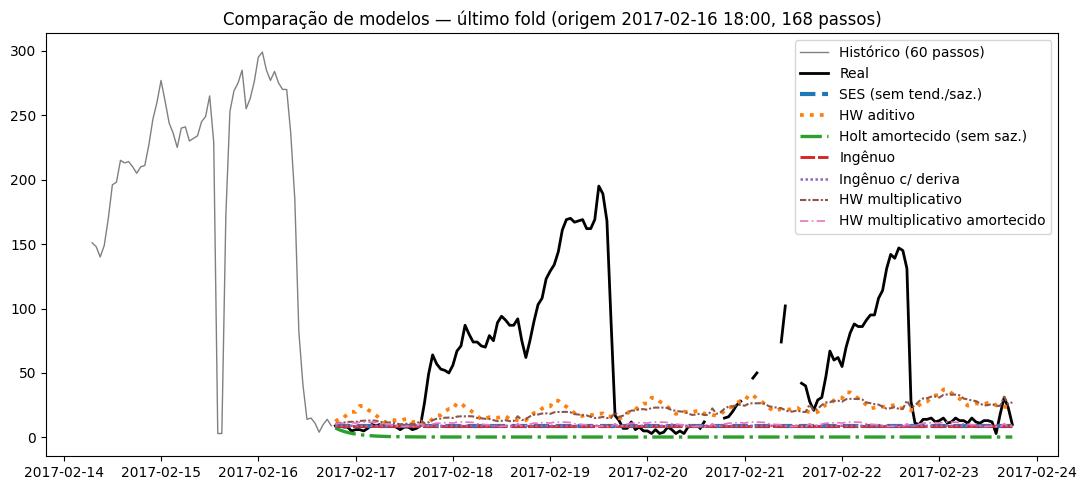

In [ ]:
# T16 — Comparação por MAE (fora da amostra, walk-forward; NaN de y_real mascarados)
tabela_mae = pd.DataFrame({
    nome: {origem: np.nanmean(np.abs(d['y_real'] - d['y_prev'])) for origem, d in df_wf.groupby('origem')}
    for nome, df_wf in wf_resultados.items()
})
assert not tabela_mae.isna().any().any(), (
    'Há NaN: fold sem nenhum ponto observado ou modelos com origens diferentes — regenere o wf_resultados.')
origens_idx = tabela_mae.index                                   # guarda as datas reais
tabela_mae.index = [f'fold {i + 1} (origem {o:{FMT_DATA}})' for i, o in enumerate(origens_idx)]
print('MAE por fold:')
display(tabela_mae.round(2))

posicoes = tabela_mae.rank(axis=1, method='min')                 # 1 = melhor no fold
resumo = pd.DataFrame({
    'base': DATA_FILENAME,
    'MAE_medio': tabela_mae.mean(),
    'MAE_ultimo_fold': tabela_mae.iloc[-1],
    'vitorias': (posicoes == 1).sum(),
    'posicao_media': posicoes.mean(),
})
REF = 'Ingênuo'                                                  # ajuste ao nome usado em wf_resultados
assert REF in tabela_mae.columns, f'Inclua {REF} em wf_resultados (referência da comparação).'
resumo['MAE_vs_ingenuo_%'] = (resumo['MAE_medio'] / tabela_mae[REF].mean() - 1) * 100
resumo['folds_melhor_que_ingenuo'] = tabela_mae.lt(tabela_mae[REF], axis=0).sum()
resumo = resumo.sort_values(['posicao_media', 'MAE_medio'])
print(f'Resumo ({len(tabela_mae)} folds):')
display(resumo.round(2))

# Gráfico do último fold: real e previsões na MESMA janela (HORIZON passos) + 60 passos de contexto
ultimo = origens_idx.max()
real_ult = next(iter(wf_resultados.values())).query('origem == @ultimo')
plt.figure(figsize=(11, 5))
plt.plot(y.loc[:ultimo].iloc[-60:].index, y.loc[:ultimo].iloc[-60:].values, color='gray', lw=1,
         label='Histórico (60 passos)')
plt.plot(real_ult['data'], real_ult['y_real'], color='black', lw=2, label='Real')
estilos = ['--', ':', '-.', (0, (5, 1)), (0, (1, 1)), (0, (3, 1, 1, 1)), (0, (5, 2, 1, 2)), (0, (3, 5))]
for i, (nome, df_wf) in enumerate(wf_resultados.items()):   # estilos/espessuras distintos: as curvas planas se sobrepõem
    d = df_wf[df_wf['origem'] == ultimo]
    plt.plot(d['data'], d['y_prev'], ls=estilos[i % len(estilos)], lw=3 - 0.3 * i, label=nome)
plt.legend()
plt.title(f'Comparação de modelos — último fold (origem {ultimo:{FMT_DATA}}, {HORIZON} passos)')
plt.tight_layout()
plt.show()


## T17 — Diagnóstico dos resíduos (fora da amostra)

Análise gráfica e estatística dos **erros fora da amostra** (`y_real - y_prev` das janelas do walk-forward): série temporal dos erros, ACF, MAE por passo à frente, teste de Ljung-Box e tabela de p-valores. O resíduo in-sample do ajuste no treino entra apenas como contraste secundário.

Modelo configurado: trend=add, seasonal=add, damped=True | log=True | n resíduos = 28051


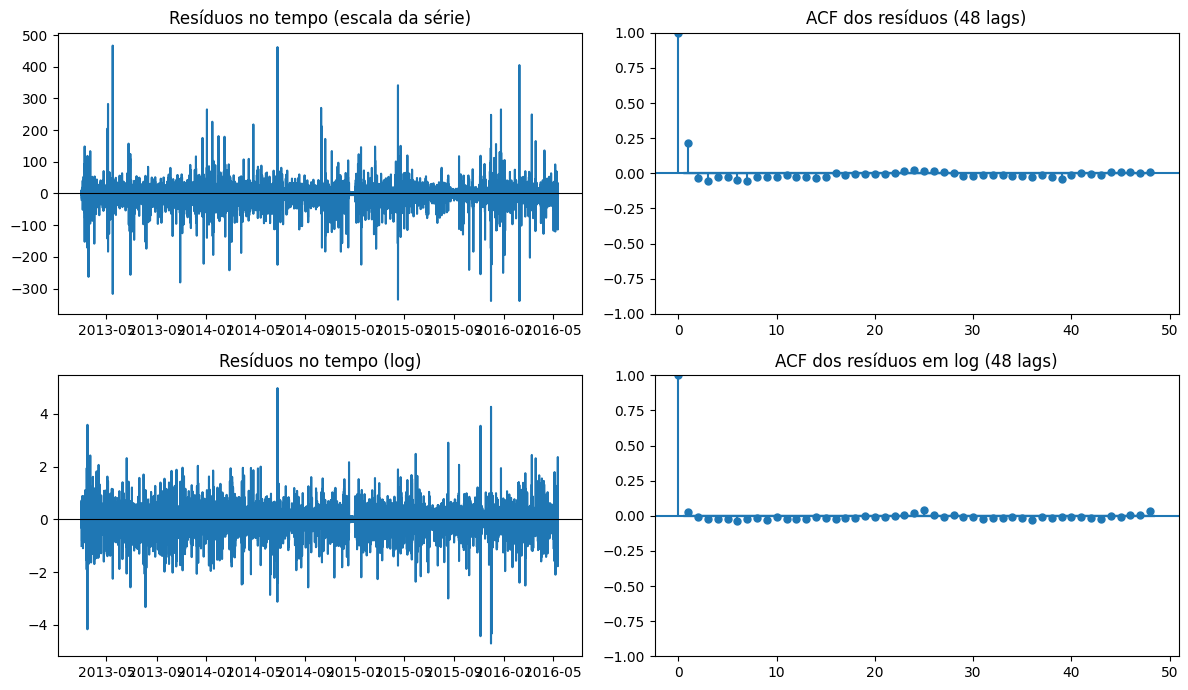

p-valores do teste de Ljung-Box:


,lag 24,lag 48,lag 168
SES (sem tend./saz.),0.0,0.0,0.0
HW aditivo,0.0,0.0,0.0
HW multiplicativo,0.0,0.0,0.0
HW multiplicativo amortecido,0.0,0.0,0.0
Holt amortecido (configurado),0.0,0.0,0.0
Holt amortecido (log),0.0,0.0,0.0


Desvio padrão dos resíduos por ano:


,std_serie,std_log
data,,
2013,21.5654,0.3563
2014,20.2557,0.3022
2015,20.2734,0.3034
2016,21.5178,0.3490


In [ ]:
# T17 — Diagnóstico dos resíduos FORA DA AMOSTRA
# O enunciado pede o erro fora da amostra: y_real - y_prev de cada janela do T08 (e não o
# resíduo in-sample de `fit.resid`, que é o erro de 1 passo dentro do treino).
# Como ORIGIN_STEP == HORIZON, as janelas são contíguas e não se sobrepõem: concatenar os
# erros produz uma série temporal contínua cobrindo todo o período de teste.
assert len(train) == n_train and pd.infer_freq(train.index) == FREQUENCY, (
    'train não é a série configurada: rode o notebook inteiro na ordem (Restart & Run All).')
assert ORIGIN_STEP == HORIZON, 'Janelas sobrepostas: os erros concatenados não formam série contínua.'


def erros_oos(df_wf):
    """Série temporal dos erros fora da amostra (NaN onde o alvo não foi observado)."""
    s = df_wf['y_real'] - df_wf['y_prev']
    s.index = pd.DatetimeIndex(df_wf['data'])
    return s.sort_index()


resid_oos = {nome: erros_oos(d) for nome, d in wf_resultados.items()}
resid = resid_oos[NOME_CFG]                    # erro fora da amostra do modelo configurado
n_falta = int(resid.isna().sum())
print(f'Modelo configurado: trend={TREND}, seasonal={SEASONAL}, damped={bool(DAMPED_TREND and TREND)}')
print(f'{len(resid)} erros fora da amostra ({N_ORIGINS} folds x {HORIZON} passos) | '
      f'{n_falta} pontos não observados (excluídos dos testes)')

LAGS_ACF = int(min(max(40, 2 * SEASONAL_PERIODS), 200, len(resid.dropna()) // 3))
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
ax[0, 0].plot(resid.index, resid.values, lw=0.7)
ax[0, 0].axhline(0, color='k', lw=0.8)
ax[0, 0].set_title('Erro fora da amostra no tempo')
plot_acf(resid.dropna(), lags=LAGS_ACF, ax=ax[0, 1])
ax[0, 1].set_title(f'ACF do erro fora da amostra ({LAGS_ACF} lags)')
ax[1, 0].hist(resid.dropna(), bins=50)
ax[1, 0].set_title('Distribuição do erro fora da amostra')
erro_por_h = pd.DataFrame({
    nome: d.assign(e=(d['y_real'] - d['y_prev']).abs()).groupby('h')['e'].mean()
    for nome, d in wf_resultados.items()})
erro_por_h.plot(ax=ax[1, 1], lw=1)
ax[1, 1].set_title('MAE por passo à frente (h)')
ax[1, 1].set_xlabel('h')
ax[1, 1].legend(fontsize=7)
plt.tight_layout()
plt.show()

# Ljung-Box no erro FORA DA AMOSTRA (H0: sem autocorrelação; p < 0.05 => rejeita H0)
LAGS = [l for l in LB_LAGS if l <= len(resid.dropna()) // 3]
tabela_lb = pd.DataFrame({nome: acorr_ljungbox(s.dropna(), lags=LAGS, return_df=True)['lb_pvalue']
                          for nome, s in resid_oos.items()}).T
tabela_lb.columns = [f'lag {l}' for l in LAGS]
print('p-valores do teste de Ljung-Box (erros fora da amostra):')
display(tabela_lb.round(4))

# Viés, dispersão e forma do erro fora da amostra
resumo_resid = pd.DataFrame({
    nome: {'media_vies': s.mean(), 'desvio': s.std(),
           'assimetria': stats.skew(s.dropna()), 'curtose_excesso': stats.kurtosis(s.dropna())}
    for nome, s in resid_oos.items()}).T
print('Resumo do erro fora da amostra (média ≠ 0 => previsão enviesada):')
display(resumo_resid.round(4))

# A variância do erro é constante ao longo do período de teste?
print('Desvio padrão do erro fora da amostra por ano:')
display(resid.groupby(resid.index.year).std().round(4).to_frame('std_erro_oos'))

# --- Secundário: resíduo DENTRO da amostra, só para contraste com o de fora ---
print(f'\n[Secundário] Ljung-Box do resíduo in-sample do ajuste no treino '
      f'({len(fit_cfg.resid)} pontos) — não é a métrica pedida pelo enunciado.')
_lb_in = pd.DataFrame({nome: acorr_ljungbox(f.resid, lags=LAGS, return_df=True)['lb_pvalue']
                       for nome, f in fits_holdout.items()}).T
_lb_in.columns = [f'lag {l}' for l in LAGS]
display(_lb_in.round(4))

## Contexto das conclusões: estatísticas de treino e teste

O teste pode conter valores que o treino nunca viu (e, nas bases com NaN no alvo, pontos mascarados): contexto para interpretar os erros de previsão.


In [ ]:
# O teste pode conter valores fora da faixa do treino: contexto para interpretar os erros de previsão
display(pd.DataFrame({'treino': train.describe(), 'teste': y_obs.iloc[n_train:].describe()}).round(0))


,treino,teste
count,28051.0,6906.0
mean,83.0,80.0
std,82.0,84.0
min,3.0,3.0
25%,23.0,20.0
50%,59.0,53.0
75%,116.0,108.0
max,898.0,713.0


## Conclusões e limitações

> **Antes do commit:** os itens abaixo são um roteiro de interpretação — rode com `Restart & Run All` e complete com os números das saídas (T04/T05, T09, T16 e T17). O notebook do grupo 1 mostra o modelo de redação com valores preenchidos.

1. **Sazonalidade.** Registrar a ACF dos lags candidatos, o limite ±1,96/√n, `F_sazonal` e `F_tend` da STL (ciclo diário de 24 h) e dizer se o modelo principal é sustentado pelo diagnóstico.
2. **Parâmetros.** Reportar α, β, γ e φ do modelo configurado, o AIC relativo entre as variantes do T09 e o que isso implica (α ≈ 1 => o nível acompanha quase só o último valor; β ≈ 0 => tendência estável).
3. **Tendência amortecida.** Comparar a previsão sem damping, com φ MLE e com φ fixo no horizonte longo (720 horas = 30 dias) e as métricas no teste (RMSE/MAE/MAPE).
4. **Walk-forward (41 folds, 168 passos).** Dizer se alguma variante Holt-Winters vence o ingênuo de forma consistente (vitórias por fold e MAE relativo, tabela do T16). Série de material particulado com ciclo diário fraco: sem sazonalidade robusta o ingênuo costuma ser difícil de vencer.
5. **Resíduos.** Ljung-Box nos lags 24, 48 e 168 h (dia, dois dias e semana), distribuição e estabilidade de variância por ano; dizer se os resíduos são compatíveis com ruído branco e se intervalos normais de previsão são confiáveis.
6. **Limitações.**
   - **NaN no teste:** 107 NaN em 7.013 horas de teste; as métricas mascaram esses pontos (contagem na carga e no T08).
   - **Interpolação:** os NaN internos são interpolados **somente para ajustar** os modelos; a avaliação usa `y_obs`.
   - **Escala:** **Log:** aplicado (PM2.5 ≥ 3 > 0) em T04/T05/T17.
   - **Parâmetros de projeto:** horizonte de 168 passos, `N_ORIGINS = 41` e `LONG_HORIZON = 720` são decisões a confirmar no enunciado.
   - **Significância:** não foi aplicado teste formal de comparação de previsões (por exemplo, Diebold-Mariano); diferenças pequenas no MAE não devem ser tratadas como significativas.


# Checklist antes do commit

- [ ] Configuração e versão da execução atualizadas.
- [ ] Separação temporal e horizonte documentados.
- [ ] Transformadores ajustados somente com dados de treino.
- [ ] Hiperparâmetros congelados antes do teste final.
- [ ] Métricas calculadas com previsões fora da amostra.
- [ ] Artefatos essenciais salvos por tarefa.
- [ ] Saídas excessivas e células temporárias removidas.

## Avaliação oficial de um passo (T08/T16)

O estudo multipasso acima permanece como análise adicional. Aqui usamos suavização exponencial em espaço de estados (nível, tendência e sazonalidade aditiva quando aplicável), selecionada por validação cronológica **dentro do treino**. O ajuste final termina antes do teste; a cada data, o estado incorpora somente o valor já observado. Valores ausentes ficam ausentes no filtro e nunca são interpolados com informação futura. A saída guarda todas as previsões nas origens oficiais para a comparação entre as quatro famílias.

In [1]:
# Holt-Winters/ETS de um passo na grade completa, com atualizacao causal do estado.
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.statespace.exponential_smoothing import ExponentialSmoothing as ETS
from statsmodels.stats.diagnostic import acorr_ljungbox
from IPython.display import display
from preparacao_bases import carregar_base_tratada
from walk_forward import origens_teste, validar_previsoes

RAIZ_OFICIAL = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'preparacao_bases.py').is_file())
BASE_OFICIAL = 'poluicao'
dados_oficiais, meta_oficial = carregar_base_tratada(BASE_OFICIAL, RAIZ_OFICIAL)
y_grade = dados_oficiais[meta_oficial['alvo']].astype(float)
indice_oficial = origens_teste(BASE_OFICIAL, RAIZ_OFICIAL)
corte_oficial = pd.Timestamp(meta_oficial['inicio_teste'])
pos_corte = y_grade.index.get_loc(corte_oficial)
frequencia_oficial = meta_oficial['frequencia']
periodo_sazonal = {'bitcoin': 7, 'trafego': 24, 'poluicao': 24, 'clima': 24, 'ouro': None}[BASE_OFICIAL]
validacao_passos = {'bitcoin': 90, 'trafego': 336, 'poluicao': 336, 'clima': 336, 'ouro': 26}[BASE_OFICIAL]
janela_ajuste = {'bitcoin': 730, 'trafego': 1000, 'poluicao': 1000, 'clima': 1000, 'ouro': 520}[BASE_OFICIAL]
assert pos_corte > validacao_passos + janela_ajuste

configuracoes = [('nivel', False, None), ('tendencia', True, None)]
if periodo_sazonal is not None:
    configuracoes.append(('tendencia_sazonal', True, periodo_sazonal))

def ajustar_ets(serie, tendencia, sazonal):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return ETS(serie, trend=tendencia, seasonal=sazonal,
                   initialization_method='estimated').fit(disp=False, maxiter=70)

linhas_ets = []
inicio_fit = pos_corte - validacao_passos - janela_ajuste
fim_fit = pos_corte - validacao_passos
y_fit_val = y_grade.iloc[inicio_fit:fim_fit]
y_val_ets = y_grade.iloc[fim_fit:pos_corte]
for nome, tendencia, sazonal in configuracoes:
    try:
        ajuste = ajustar_ets(y_fit_val, tendencia, sazonal)
        estado = ajuste.append(y_val_ets, refit=False)
        previsto = np.asarray(estado.get_prediction(
            start=len(y_fit_val), end=len(y_fit_val)+len(y_val_ets)-1,
            dynamic=False).predicted_mean)
        observado = y_val_ets.notna().to_numpy()
        mae = mean_absolute_error(y_val_ets.to_numpy()[observado], previsto[observado])
        linhas_ets.append({'configuracao': nome, 'trend': tendencia,
            'seasonal': sazonal, 'MAE_validacao': mae,
            'convergiu': bool(ajuste.mle_retvals.get('converged', False))})
    except Exception as exc:
        linhas_ets.append({'configuracao': nome, 'trend': tendencia,
            'seasonal': sazonal, 'MAE_validacao': np.nan,
            'convergiu': False, 'falha': str(exc)[:120]})
tabela_ets = pd.DataFrame(linhas_ets).dropna(subset=['MAE_validacao']).sort_values(
    ['convergiu','MAE_validacao'], ascending=[False,True]).reset_index(drop=True)
if tabela_ets.empty:
    raise RuntimeError(f'Nenhum ETS ajustado para {BASE_OFICIAL}: {linhas_ets}')
display(tabela_ets)
escolha_ets = tabela_ets.iloc[0]

# Reajuste antes do teste e previsao um passo adiante a cada data da grade.
y_ajuste_ets = y_grade.iloc[pos_corte-janela_ajuste:pos_corte]
y_teste_ets = y_grade.iloc[pos_corte:]
modelo_ets = ajustar_ets(y_ajuste_ets, bool(escolha_ets['trend']),
                         None if pd.isna(escolha_ets['seasonal']) else int(escolha_ets['seasonal']))
estado_teste_ets = modelo_ets.append(y_teste_ets, refit=False)
prev_grade_ets = np.asarray(estado_teste_ets.get_prediction(
    start=len(y_ajuste_ets), end=len(y_ajuste_ets)+len(y_teste_ets)-1,
    dynamic=False).predicted_mean)
prev_grade_ets = pd.Series(prev_grade_ets, index=y_teste_ets.index)
previsoes_ets = pd.DataFrame({'real': y_teste_ets.reindex(indice_oficial),
    'previsto': prev_grade_ets.reindex(indice_oficial)}, index=indice_oficial)
assert previsoes_ets.notna().all().all()
conferencia_ets = validar_previsoes(BASE_OFICIAL, previsoes_ets.index, RAIZ_OFICIAL)
assert conferencia_ets['ok'], conferencia_ets
mae_ets = mean_absolute_error(previsoes_ets.real, previsoes_ets.previsto)
mae_naive = mean_absolute_error(previsoes_ets.real, y_grade.shift(1).reindex(indice_oficial))
erros_ets = previsoes_ets.real - previsoes_ets.previsto
print(f'MAE OFICIAL T08 HOLT-WINTERS {BASE_OFICIAL}: {mae_ets:.4f} | n={len(previsoes_ets):,}')
print(f'MAE persistencia nas mesmas datas: {mae_naive:.4f}')
print(f'Configuracao escolhida no treino: {escolha_ets["configuracao"]} | convergiu no ajuste final: {modelo_ets.mle_retvals.get("converged", False)}')
print(f'Datas: {previsoes_ets.index.min()} a {previsoes_ets.index.max()}')
display(acorr_ljungbox(erros_ets, lags=[min(24,len(erros_ets)//5)], return_df=True))

# T16 le as previsoes completas desta saida do notebook.
carga_previsoes_ets = {'data': [d.isoformat() for d in previsoes_ets.index],
    'real': previsoes_ets.real.astype(float).tolist(),
    'previsto': previsoes_ets.previsto.astype(float).tolist()}
display({'application/vnd.series-temporais.previsoes+json': carga_previsoes_ets}, raw=True)


,configuracao,trend,seasonal,MAE_validacao,convergiu
0,nivel,False,NaN,12.751817,True
1,tendencia,True,NaN,12.791056,True
2,tendencia_sazonal,True,24.0,12.981798,False


MAE OFICIAL T08 HOLT-WINTERS poluicao: 10.3912 | n=6,336
MAE persistencia nas mesmas datas: 10.3906
Configuracao escolhida no treino: nivel | convergiu no ajuste final: True
Datas: 2016-05-12 19:00:00 a 2017-02-28 23:00:00


,lb_stat,lb_pvalue
24,729.662273,1.415675e-138
